## Загружаем библиотеки и данные

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import catboost

from catboost import CatBoostClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
from metric import precision_at_recall, pr_curve, recall_at_fpr


In [3]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
events_raw = pd.read_csv('data/events.csv.gz')
sample_submission = pd.read_csv('sample_submission.csv')

print('train', train.shape)
print('test', test.shape)
print('events', events_raw.shape)
print('sample_submission', sample_submission.shape)

train (11091, 5)
test (4909, 4)
events (328905, 14)
sample_submission (4909, 2)


В train 11 091 кука, в test 4 909 кук. Одна модель должна обработать все 16 000 кук одинаково.

## Повторяем подготовку событий из EDA

Временные поля переводим в datetime. Метаданные train и test объединяем без target. Объединение нужно только для одинаковой фильтрации событий по окну.

In [4]:
for frame in [train, test]:
    for column in ['cookie_created_at', 'window_start_ts', 'window_end_ts']:
        frame[column] = pd.to_datetime(frame[column])

events_raw['event_ts'] = pd.to_datetime(events_raw['event_ts'])

meta = pd.concat([
    train.drop(columns='target').assign(dataset='train'),
    test.assign(dataset='test')
], ignore_index=True)

meta['age_days'] = (
    meta['window_end_ts'] - meta['cookie_created_at']
).dt.total_seconds() / 86400

In [5]:
events_audit = events_raw.merge(
    meta[['cookie_id', 'window_start_ts', 'window_end_ts']],
    on='cookie_id',
    validate='many_to_one'
)

inside_window = (
    events_audit['event_ts'].ge(events_audit['window_start_ts']) &
    events_audit['event_ts'].lt(events_audit['window_end_ts'])
)

events_window = events_audit.loc[inside_window, events_raw.columns].copy()
full_duplicates = events_window.duplicated()
events = events_window.loc[~full_duplicates].copy()

events['platform'] = (
    events['platform']
    .astype('string')
    .str.strip()
    .str.lower()
    .replace({'desktop': 'web', 'iphone': 'ios'})
)

events = events.sort_values(
    ['cookie_id', 'event_ts'],
    kind='stable'
).reset_index(drop=True)

preparation_result = pd.DataFrame({
    'Показатель': [
        'Исходные события',
        'События вне окна',
        'Полные дубли внутри окна',
        'События для признаков'
    ],
    'Значение': [
        len(events_raw),
        (~inside_window).sum(),
        full_duplicates.sum(),
        len(events)
    ]
})

display(preparation_result)

,Показатель,Значение
0,Исходные события,328905
1,События вне окна,40779
2,Полные дубли внутри окна,4293
3,События для признаков,283833


Для признаков осталось 283 833 события. Исключено 40 779 событий вне окна и 4 293 полных дубля.

## Создаём одну строку на куку

cookie_id остаётся индексом. window_start_ts нужен только для временного разбиения. В модель эти два поля не передаются.

In [6]:
cookie_features = meta.set_index('cookie_id')[
    ['dataset', 'window_start_ts', 'age_days']
].copy()

by_cookie = events.groupby('cookie_id')

cookie_features['n_events'] = by_cookie.size().reindex(
    cookie_features.index,
    fill_value=0
)
cookie_features['n_items'] = by_cookie['item_id'].nunique().reindex(
    cookie_features.index,
    fill_value=0
)
cookie_features['platform'] = (
    by_cookie['platform']
    .first()
    .reindex(cookie_features.index)
    .fillna('unknown')
)

actions = sorted(events['event_name'].unique())

action_counts = pd.crosstab(
    events['cookie_id'],
    events['event_name']
).reindex(
    index=cookie_features.index,
    columns=actions,
    fill_value=0
)

for action in actions:
    cookie_features[f'n_{action}'] = action_counts[action]
    cookie_features[f'share_{action}'] = (
        action_counts[action] / cookie_features['n_events'].replace(0, np.nan)
    )

print('Типы событий', actions)
display(cookie_features.head())

Типы событий ['contact_chat_open', 'contact_message_sent', 'contact_phone_show', 'favorite_add', 'item_view', 'login', 'photo_swipe', 'search_results_view', 'seller_page_view']


,dataset,window_start_ts,age_days,n_events,n_items,platform,n_contact_chat_open,share_contact_chat_open,n_contact_message_sent,share_contact_message_sent,...,n_item_view,share_item_view,n_login,share_login,n_photo_swipe,share_photo_swipe,n_search_results_view,share_search_results_view,n_seller_page_view,share_seller_page_view
cookie_id,,,,,,,,,,,,,,,,,,,,,
ck_54a059eb7d3ea68b,train,2026-04-06,136.603692,7,4,android,0,0.000000,0,0.000000,...,3,0.428571,0,0.000000,1,0.142857,3,0.428571,0,0.000000
ck_7e4de46eeab82974,train,2026-04-06,195.576111,41,19,web,0,0.000000,0,0.000000,...,22,0.536585,1,0.024390,4,0.097561,8,0.195122,4,0.097561
ck_9320229ef6304522,train,2026-04-06,33.994421,36,19,web,1,0.027778,1,0.027778,...,7,0.194444,3,0.083333,3,0.083333,13,0.361111,3,0.083333
ck_30ccd25bc1714ed9,train,2026-04-06,1.546759,21,10,web,1,0.047619,0,0.000000,...,14,0.666667,0,0.000000,0,0.000000,3,0.142857,2,0.095238
ck_a77c5f05948cdeef,train,2026-04-06,95.837095,28,16,web,0,0.000000,0,0.000000,...,12,0.428571,0,0.000000,4,0.142857,6,0.214286,3,0.107143


Количество действия описывает объём. Доля действия описывает состав истории. Оба варианта сохраняем.

## Добавляем ритм активности

EDA показал разницу в паузах и локальной скорости. Считаем активные минуты и часы, длину истории, квантили пауз и число сессий.

In [7]:
events['minute'] = events['event_ts'].dt.floor('min')
events['hour'] = events['event_ts'].dt.floor('h')

cookie_features['active_minutes'] = events.groupby('cookie_id')['minute'].nunique().reindex(
    cookie_features.index,
    fill_value=0
)
cookie_features['active_hours'] = events.groupby('cookie_id')['hour'].nunique().reindex(
    cookie_features.index,
    fill_value=0
)

events_per_minute = events.groupby(['cookie_id', 'minute']).size()
cookie_features['max_events_minute'] = events_per_minute.groupby('cookie_id').max().reindex(
    cookie_features.index,
    fill_value=0
)
cookie_features['active_minute_share'] = (
    cookie_features['max_events_minute'] /
    cookie_features['n_events'].replace(0, np.nan)
)

first_event = by_cookie['event_ts'].min()
last_event = by_cookie['event_ts'].max()
cookie_features['event_span_minutes'] = (
    last_event - first_event
).dt.total_seconds() / 60

events['gap_seconds'] = (
    events.groupby('cookie_id')['event_ts']
    .diff()
    .dt.total_seconds()
)

gaps = events.groupby('cookie_id')['gap_seconds']

cookie_features['gap_median'] = gaps.median()
cookie_features['gap_p10'] = gaps.quantile(0.10)
cookie_features['gap_q25'] = gaps.quantile(0.25)
cookie_features['gap_q75'] = gaps.quantile(0.75)
cookie_features['gap_p90'] = gaps.quantile(0.90)
cookie_features['gap_std'] = gaps.std()
cookie_features['gap_iqr'] = cookie_features['gap_q75'] - cookie_features['gap_q25']

known_gaps = events.loc[events['gap_seconds'].notna()]
cookie_features['fast_gap_share'] = (
    known_gaps['gap_seconds'].le(10)
    .groupby(known_gaps['cookie_id'])
    .mean()
)
cookie_features['zero_gap_share'] = (
    known_gaps['gap_seconds'].eq(0)
    .groupby(known_gaps['cookie_id'])
    .mean()
)

In [8]:
events['new_session'] = (
    events['gap_seconds'].isna() |
    events['gap_seconds'].gt(30 * 60)
)
events['session'] = events['new_session'].groupby(events['cookie_id']).cumsum()

sessions = events.groupby(['cookie_id', 'session']).agg(
    first_event=('event_ts', 'min'),
    last_event=('event_ts', 'max'),
    n_events=('event_ts', 'size')
)
sessions['duration_minutes'] = (
    sessions['last_event'] - sessions['first_event']
).dt.total_seconds() / 60

cookie_features['n_sessions'] = sessions.groupby(level=0).size().reindex(
    cookie_features.index,
    fill_value=0
)
cookie_features['session_duration_median'] = sessions.groupby(level=0)[
    'duration_minutes'
].median()

У куки с одним событием интервалы остаются пропусками. CatBoost умеет работать с такими значениями. Ноль здесь означал бы событие без паузы и изменил смысл признака.

## Добавляем просмотры и интересы

Используем число объявлений, повторные просмотры, категории, локации и тип продавца. Концентрация считается среди известных значений.

In [9]:
item_views = events.loc[events['event_name'].eq('item_view')].copy()
item_groups = item_views.groupby('cookie_id')

cookie_features['unique_viewed_items'] = item_groups['item_id'].nunique().reindex(
    cookie_features.index,
    fill_value=0
)
cookie_features['repeat_view_share'] = (
    1 - cookie_features['unique_viewed_items'] /
    cookie_features['n_item_view'].replace(0, np.nan)
)
cookie_features['unique_categories'] = item_groups['item_category'].nunique().reindex(
    cookie_features.index,
    fill_value=0
)
cookie_features['unique_locations'] = item_groups['item_location'].nunique().reindex(
    cookie_features.index,
    fill_value=0
)

known_categories = item_views.dropna(subset=['item_category'])
known_locations = item_views.dropna(subset=['item_location'])

category_counts = known_categories.groupby(
    ['cookie_id', 'item_category']
).size()
location_counts = known_locations.groupby(
    ['cookie_id', 'item_location']
).size()

cookie_features['category_focus'] = (
    category_counts.groupby(level=0).max() /
    known_categories.groupby('cookie_id').size()
)
cookie_features['location_focus'] = (
    location_counts.groupby(level=0).max() /
    known_locations.groupby('cookie_id').size()
)
cookie_features['pro_seller_share'] = (
    item_views['seller_type'].eq('pro')
    .groupby(item_views['cookie_id'])
    .mean()
)

## Добавляем поиск и контакты

Глубина поиска оказалась полезнее самого наличия поиска. Контакты не разделяли классы сами по себе, но остаются частью поведения.

In [10]:
searches = events.loc[
    events['event_name'].eq('search_results_view')
].copy()

searches['query_normalized'] = (
    searches['search_query']
    .astype('string')
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
    .replace('', pd.NA)
)

search_groups = searches.groupby('cookie_id')

cookie_features['unique_queries'] = search_groups['query_normalized'].nunique().reindex(
    cookie_features.index,
    fill_value=0
)
cookie_features['max_search_page'] = search_groups['search_page'].max()
cookie_features['mean_search_page'] = search_groups['search_page'].mean()
cookie_features['deep_search_share'] = (
    searches['search_page'].ge(5)
    .groupby(searches['cookie_id'])
    .mean()
)

contact_actions = [
    'contact_phone_show',
    'contact_chat_open',
    'contact_message_sent'
]

cookie_features['n_contacts'] = action_counts[contact_actions].sum(axis=1)
cookie_features['has_contact'] = cookie_features['n_contacts'].gt(0).astype(int)
cookie_features['contacts_per_view'] = (
    cookie_features['n_contacts'] /
    cookie_features['n_item_view'].replace(0, np.nan)
)

## Добавляем технические признаки

Возраст куки, платформа, User-Agent и координаты дали различия в EDA. Полный текст User-Agent не передаём. Используем число вариантов и фиксированный список технических маркеров.

In [11]:
cookie_features['n_user_agents'] = by_cookie['user_agent'].nunique().reindex(
    cookie_features.index,
    fill_value=0
)

automation_pattern = (
    r'headlesschrome|python-requests|python-urllib|scrapy|curl/|'
    r'go-http-client|node-fetch|wget|aiohttp|httpx'
)

events['has_automation_marker'] = (
    events['user_agent']
    .fillna('')
    .str.lower()
    .str.contains(automation_pattern, regex=True)
)

cookie_features['has_automation_marker'] = (
    events.groupby('cookie_id')['has_automation_marker']
    .any()
    .reindex(cookie_features.index, fill_value=False)
    .astype(int)
)

pointer_events = events.dropna(subset=['pointer_x', 'pointer_y']).groupby(
    'cookie_id'
).size()

cookie_features['pointer_share'] = (
    pointer_events.reindex(cookie_features.index, fill_value=0) /
    cookie_features['n_events'].replace(0, np.nan)
)

events['previous_event'] = events.groupby('cookie_id')['event_name'].shift()
events['previous_ts'] = events.groupby('cookie_id')['event_ts'].shift()

valid_transition = (
    events['previous_ts'].notna() &
    events['event_ts'].gt(events['previous_ts'])
)
same_action = (
    valid_transition &
    events['event_name'].eq(events['previous_event'])
)

transition_count = events.loc[valid_transition].groupby('cookie_id').size()
same_action_count = events.loc[same_action].groupby('cookie_id').size()

cookie_features['same_action_share'] = (
    same_action_count /
    transition_count.replace(0, np.nan)
)

## Проверяем таблицу признаков

Одна строка должна соответствовать одной куке. target не должен находиться в общей таблице. Бесконечные значения недопустимы.

In [12]:
numeric_values = cookie_features.select_dtypes('number').to_numpy()

feature_checks = pd.DataFrame({
    'Проверка': [
        'Одна строка на cookie_id',
        'Сохранены все куки',
        'target отсутствует в признаках',
        'Нет бесконечных значений',
        'Нет кук без событий'
    ],
    'Результат': [
        cookie_features.index.is_unique,
        len(cookie_features) == len(meta),
        'target' not in cookie_features.columns,
        not np.isinf(numeric_values).any(),
        cookie_features['n_events'].gt(0).all()
    ]
})

display(feature_checks)
print('Размер таблицы', cookie_features.shape)
print('Числовых пропусков', cookie_features.select_dtypes('number').isna().sum().sum())

,Проверка,Результат
0,Одна строка на cookie_id,True
1,Сохранены все куки,True
2,target отсутствует в признаках,True
3,Нет бесконечных значений,True
4,Нет кук без событий,True


Размер таблицы (16000, 58)
Числовых пропусков 15920


Пропуски остаются только там, где показатель нельзя посчитать. Они не заменяются нулём автоматически.

In [13]:
from itertools import product
from scipy.stats import ks_2samp
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

## Расширяем признаки сессий

EDA показал разницу в плотности действий. Добавляем размер и длительность самой большой сессии, средний размер сессии и скорость активности.

In [14]:
session_features = pd.DataFrame(index=cookie_features.index)

session_features['session_events_max'] = sessions.groupby(level=0)['n_events'].max()
session_features['session_events_mean'] = sessions.groupby(level=0)['n_events'].mean()
session_features['session_events_std'] = sessions.groupby(level=0)['n_events'].std()
session_features['session_duration_max'] = sessions.groupby(level=0)['duration_minutes'].max()
session_features['largest_session_share'] = (
    session_features['session_events_max'] /
    cookie_features['n_events'].replace(0, np.nan)
)
session_features['events_per_active_minute'] = (
    cookie_features['n_events'] /
    cookie_features['active_minutes'].replace(0, np.nan)
)
session_features['events_per_active_hour'] = (
    cookie_features['n_events'] /
    cookie_features['active_hours'].replace(0, np.nan)
)
session_features['long_gap_share'] = (
    known_gaps['gap_seconds'].gt(30 * 60)
    .groupby(known_gaps['cookie_id'])
    .mean()
)
session_features['gap_mean'] = gaps.mean()
session_features['gap_cv'] = gaps.std() / session_features['gap_mean'].replace(0, np.nan)

cookie_features = pd.concat([cookie_features, session_features], axis=1)

session_feature_names = session_features.columns.tolist()
display(cookie_features[session_feature_names].describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
session_events_max,16000.0,9.78,8.09,1.00,4.00,8.00,13.00,129.00
session_events_mean,16000.0,6.20,4.98,1.00,3.00,5.00,7.67,94.00
session_events_std,11631.0,4.24,3.95,0.00,1.72,3.25,5.61,71.97
session_duration_max,16000.0,13.45,14.50,0.00,3.83,8.20,19.12,275.00
largest_session_share,16000.0,0.68,0.25,0.12,0.47,0.67,1.00,1.00
events_per_active_minute,16000.0,1.51,0.73,1.00,1.15,1.33,1.62,13.50
events_per_active_hour,16000.0,5.74,4.50,1.00,3.00,4.67,7.00,94.00
long_gap_share,15641.0,0.14,0.15,0.00,0.00,0.11,0.20,1.00
gap_mean,15641.0,824.43,851.18,0.00,217.00,645.25,1117.31,9005.00
gap_cv,15049.0,2.08,1.00,0.00,1.39,2.08,2.67,10.80


## Считаем ритм отдельных действий

Общая медианная пауза была сильным признаком. Здесь считаем паузу между событиями одного типа и максимальное число таких событий за минуту.

In [15]:
same_action_gap = (
    events.groupby(['cookie_id', 'event_name'])['event_ts']
    .diff()
    .dt.total_seconds()
)

action_gap_table = events[['cookie_id', 'event_name']].copy()
action_gap_table['same_action_gap'] = same_action_gap

action_gap_table = action_gap_table.pivot_table(
    index='cookie_id',
    columns='event_name',
    values='same_action_gap',
    aggfunc='median'
)
action_gap_table = action_gap_table.reindex(columns=actions)
action_gap_table.columns = [
    f'same_action_gap_{action}' for action in action_gap_table.columns
]

action_minute_table = (
    events.groupby(['cookie_id', 'event_name', 'minute'])
    .size()
    .groupby(level=[0, 1])
    .max()
    .unstack()
    .reindex(columns=actions)
    .fillna(0)
)
action_minute_table.columns = [
    f'max_minute_{action}' for action in action_minute_table.columns
]

action_timing_features = pd.concat([
    action_gap_table,
    action_minute_table
], axis=1).reindex(cookie_features.index)

cookie_features = pd.concat([cookie_features, action_timing_features], axis=1)
action_timing_feature_names = action_timing_features.columns.tolist()

print('Новых признаков ритма действий', len(action_timing_feature_names))

Новых признаков ритма действий 18


## Считаем переходы между действиями

Полные последовательности из EDA не разделяли классы. Короткие переходы могут быть устойчивее. Переход учитывается только при увеличении event_ts.

In [16]:
transition_rows = events.loc[
    valid_transition,
    ['cookie_id', 'previous_event', 'event_name']
].copy()
transition_rows['transition'] = (
    transition_rows['previous_event'] + '__' + transition_rows['event_name']
)

all_transitions = [
    previous + '__' + current
    for previous, current in product(actions, actions)
]

transition_counts = pd.crosstab(
    transition_rows['cookie_id'],
    transition_rows['transition']
).reindex(
    index=cookie_features.index,
    columns=all_transitions,
    fill_value=0
)
transition_counts.columns = [
    'tr_' + column for column in transition_counts.columns
]

transition_total = transition_counts.sum(axis=1)
transition_proportions = transition_counts.div(
    transition_total.replace(0, np.nan),
    axis=0
)
transition_log = np.log(transition_proportions.where(transition_proportions.gt(0)))

transition_summary = pd.DataFrame(index=cookie_features.index)
transition_summary['unique_transitions'] = transition_counts.gt(0).sum(axis=1)
transition_summary['transition_entropy'] = -(
    transition_proportions * transition_log
).sum(axis=1)
transition_summary['transition_entropy_normalized'] = (
    transition_summary['transition_entropy'] /
    np.log(transition_summary['unique_transitions']).replace(0, np.nan)
)

same_action_transition = (
    valid_transition &
    events['event_name'].eq(events['previous_event'])
)
run_id = (~same_action_transition).groupby(events['cookie_id']).cumsum()
action_runs = events.groupby([events['cookie_id'], run_id]).size()
transition_summary['same_action_run_max'] = action_runs.groupby(level=0).max()

transition_features = pd.concat([
    transition_counts,
    transition_summary
], axis=1)

cookie_features = pd.concat([cookie_features, transition_features], axis=1)
transition_feature_names = transition_features.columns.tolist()

print('Новых признаков переходов', len(transition_feature_names))

Новых признаков переходов 85


/opt/miniconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Добавляем концентрацию поведения

category_focus и location_focus уже показали связь с target. Энтропия дополняет их и учитывает всё распределение значений. Низкая энтропия соответствует концентрации на небольшом числе значений.

In [17]:
concentration_features = pd.DataFrame(index=cookie_features.index)

action_proportions = action_counts.div(
    action_counts.sum(axis=1).replace(0, np.nan),
    axis=0
)
action_log = np.log(action_proportions.where(action_proportions.gt(0)))
action_unique = action_counts.gt(0).sum(axis=1)
concentration_features['action_entropy'] = -(
    action_proportions * action_log
).sum(axis=1)
concentration_features['action_entropy_normalized'] = (
    concentration_features['action_entropy'] /
    np.log(action_unique).replace(0, np.nan)
)

item_counts = item_views.dropna(subset=['item_id']).groupby(
    ['cookie_id', 'item_id']
).size()
item_total = item_counts.groupby(level=0).transform('sum')
item_proportions = item_counts / item_total
item_unique = item_counts.groupby(level=0).size()
concentration_features['item_entropy'] = -(
    item_proportions * np.log(item_proportions)
).groupby(level=0).sum()
concentration_features['item_entropy_normalized'] = (
    concentration_features['item_entropy'] /
    np.log(item_unique).replace(0, np.nan)
)
concentration_features['item_focus'] = (
    item_counts.groupby(level=0).max() /
    item_counts.groupby(level=0).sum()
)

category_counts = item_views.dropna(subset=['item_category']).groupby(
    ['cookie_id', 'item_category']
).size()
category_total = category_counts.groupby(level=0).transform('sum')
category_proportions = category_counts / category_total
category_unique = category_counts.groupby(level=0).size()
concentration_features['category_entropy'] = -(
    category_proportions * np.log(category_proportions)
).groupby(level=0).sum()
concentration_features['category_entropy_normalized'] = (
    concentration_features['category_entropy'] /
    np.log(category_unique).replace(0, np.nan)
)

location_counts = item_views.dropna(subset=['item_location']).groupby(
    ['cookie_id', 'item_location']
).size()
location_total = location_counts.groupby(level=0).transform('sum')
location_proportions = location_counts / location_total
location_unique = location_counts.groupby(level=0).size()
concentration_features['location_entropy'] = -(
    location_proportions * np.log(location_proportions)
).groupby(level=0).sum()
concentration_features['location_entropy_normalized'] = (
    concentration_features['location_entropy'] /
    np.log(location_unique).replace(0, np.nan)
)

concentration_features['unique_item_ratio'] = (
    cookie_features['unique_viewed_items'] /
    cookie_features['n_item_view'].replace(0, np.nan)
)
concentration_features['category_per_view'] = (
    cookie_features['unique_categories'] /
    cookie_features['n_item_view'].replace(0, np.nan)
)
concentration_features['location_per_view'] = (
    cookie_features['unique_locations'] /
    cookie_features['n_item_view'].replace(0, np.nan)
)

In [18]:
query_counts = searches.dropna(subset=['query_normalized']).groupby(
    ['cookie_id', 'query_normalized']
).size()
query_total = query_counts.groupby(level=0).transform('sum')
query_proportions = query_counts / query_total
query_unique = query_counts.groupby(level=0).size()

concentration_features['query_entropy'] = -(
    query_proportions * np.log(query_proportions)
).groupby(level=0).sum()
concentration_features['query_entropy_normalized'] = (
    concentration_features['query_entropy'] /
    np.log(query_unique).replace(0, np.nan)
)
concentration_features['query_repeat_share'] = (
    1 - cookie_features['unique_queries'] /
    cookie_features['n_search_results_view'].replace(0, np.nan)
)
concentration_features['query_length_mean'] = (
    searches['query_normalized'].str.len()
    .groupby(searches['cookie_id'])
    .mean()
)
concentration_features['query_words_mean'] = (
    searches['query_normalized'].str.split().str.len()
    .groupby(searches['cookie_id'])
    .mean()
)

searches['previous_query'] = searches.groupby('cookie_id')['query_normalized'].shift()
searches['previous_page'] = searches.groupby('cookie_id')['search_page'].shift()
searches['previous_ts'] = searches.groupby('cookie_id')['event_ts'].shift()

comparable_search = (
    searches['previous_ts'].notna() &
    searches['event_ts'].gt(searches['previous_ts']) &
    searches['query_normalized'].notna() &
    searches['query_normalized'].eq(searches['previous_query']) &
    searches['search_page'].notna() &
    searches['previous_page'].notna()
)
next_page = (
    comparable_search &
    searches['search_page'].eq(searches['previous_page'] + 1)
)

comparable_count = searches.loc[comparable_search].groupby('cookie_id').size()
next_page_count = searches.loc[next_page].groupby('cookie_id').size()

concentration_features['comparable_search_pairs'] = comparable_count.reindex(
    cookie_features.index,
    fill_value=0
)
concentration_features['next_page_share'] = (
    next_page_count /
    comparable_count.replace(0, np.nan)
)

cookie_features = pd.concat([cookie_features, concentration_features], axis=1)
concentration_feature_names = concentration_features.columns.tolist()

print('Новых признаков концентрации', len(concentration_feature_names))

Новых признаков концентрации 19


## Добавляем время активности

Час относится к времени в файле. Интерпретировать его как режим сна пользователя нельзя. Этот блок проверяется отдельно и не попадает в модель автоматически.

In [19]:
events['event_hour'] = events['event_ts'].dt.hour

time_features = pd.DataFrame(index=cookie_features.index)
time_features['share_night'] = events['event_hour'].lt(6).groupby(events['cookie_id']).mean()
time_features['share_morning'] = events['event_hour'].between(6, 11).groupby(events['cookie_id']).mean()
time_features['share_day'] = events['event_hour'].between(12, 17).groupby(events['cookie_id']).mean()
time_features['share_evening'] = events['event_hour'].ge(18).groupby(events['cookie_id']).mean()
time_features['first_event_hour'] = events.groupby('cookie_id')['event_hour'].first()
time_features['last_event_hour'] = events.groupby('cookie_id')['event_hour'].last()

cookie_features = pd.concat([cookie_features, time_features], axis=1)
time_feature_names = time_features.columns.tolist()

## Расширяем технические признаки

EDA показал сильную разницу заполненности координат внутри web. Добавляем разнообразие координат и их разброс. User-Agent разбираем на крупные семейства и сохраняем первое значение как категорию.

In [20]:
user_agent_lower = events['user_agent'].fillna('').str.lower()

events['browser_family'] = np.select(
    [
        user_agent_lower.str.contains(
            'headless|python|scrapy|curl/|wget|aiohttp|httpx|go-http-client|node-fetch'
        ),
        user_agent_lower.str.contains('edg/'),
        user_agent_lower.str.contains('firefox/'),
        user_agent_lower.str.contains('chrome/'),
        user_agent_lower.str.contains('safari/')
    ],
    ['automation', 'edge', 'firefox', 'chrome', 'safari'],
    default='other'
)

events['os_family'] = np.select(
    [
        user_agent_lower.str.contains('android'),
        user_agent_lower.str.contains('iphone|ipad|ios'),
        user_agent_lower.str.contains('windows'),
        user_agent_lower.str.contains('macintosh|mac os'),
        user_agent_lower.str.contains('linux')
    ],
    ['android', 'ios', 'windows', 'macos', 'linux'],
    default='other'
)

technical_features = pd.DataFrame(index=cookie_features.index)
technical_features['browser_family'] = events.groupby('cookie_id')['browser_family'].first()
technical_features['os_family'] = events.groupby('cookie_id')['os_family'].first()
technical_features['n_browser_families'] = events.groupby('cookie_id')['browser_family'].nunique()
technical_features['n_os_families'] = events.groupby('cookie_id')['os_family'].nunique()
technical_features['user_agent_first'] = (
    events.groupby('cookie_id')['user_agent']
    .first()
    .fillna('unknown')
)

In [21]:
pointer_events = events.dropna(subset=['pointer_x', 'pointer_y']).copy()
pointer_events['position'] = (
    pointer_events['pointer_x'].astype('string') + '_' +
    pointer_events['pointer_y'].astype('string')
)

pointer_count = pointer_events.groupby('cookie_id').size()
pointer_unique = pointer_events.groupby('cookie_id')['position'].nunique()

technical_features['pointer_unique_positions'] = pointer_unique.reindex(
    cookie_features.index,
    fill_value=0
)
technical_features['pointer_unique_share'] = (
    pointer_unique /
    pointer_count.replace(0, np.nan)
)
technical_features['pointer_x_std'] = pointer_events.groupby('cookie_id')['pointer_x'].std()
technical_features['pointer_y_std'] = pointer_events.groupby('cookie_id')['pointer_y'].std()

cookie_features = pd.concat([cookie_features, technical_features], axis=1)
technical_feature_names = technical_features.columns.tolist()

print('Новых технических признаков', len(technical_feature_names))
print('Общий размер таблицы', cookie_features.shape)

Новых технических признаков 9
Общий размер таблицы (16000, 205)


## Проверяем главный новый сигнал

pointer_x_std определён только при наличии хотя бы двух координат. Сравнение проводится внутри платформы, чтобы не смешивать web с мобильными событиями.

In [22]:
labels = train.set_index('cookie_id')['target']
model_data = cookie_features.loc[labels.index].join(
    labels,
    validate='one_to_one'
)
development_data = model_data.loc[
    model_data['window_start_ts'].lt(pd.Timestamp('2026-04-17'))
]

pointer_audit = development_data.groupby(['platform', 'target']).agg(
    cookies=('target', 'size'),
    pointer_positions_median=('pointer_unique_positions', 'median'),
    pointer_share_median=('pointer_share', 'median'),
    pointer_std_known=('pointer_x_std', 'count'),
    pointer_std_median=('pointer_x_std', 'median')
)

display(pointer_audit.round(2))

cookies  pointer_positions_median  pointer_share_median  \
platform target                                                            
android  0          3564                       0.0                  0.00   
         1           231                       0.0                  0.00   
ios      0           450                       0.0                  0.00   
         1            22                       0.0                  0.00   
web      0          4387                       6.0                  0.93   
         1           486                       0.0                  0.00   

                 pointer_std_known  pointer_std_median  
platform target                                         
android  0                       0                 NaN  
         1                       0                 NaN  
ios      0                       0                 NaN  
         1                       0                 NaN  
web      0                    3028              553.04  
         1                     205              201.66

На Android и iOS координат нет. Внутри web pointer_x_std рассчитан для 3 028 из 4 387 человеческих кук и для 205 из 486 положительных. Медианный разброс X равен 553 у людей и 202 у ботов. Признак доступен в момент события и не использует target.

## Формируем группы признаков

Baseline сохраняется без изменений. Новые блоки добавляются по одному. Так видно, какой блок даёт прирост.

In [23]:
volume_features = [
    'n_events', 'n_items', 'active_minutes', 'active_hours', 'event_span_minutes'
]

rhythm_features = [
    'max_events_minute', 'active_minute_share', 'gap_median', 'gap_p10',
    'gap_q25', 'gap_q75', 'gap_p90', 'gap_std', 'gap_iqr',
    'fast_gap_share', 'zero_gap_share', 'n_sessions', 'session_duration_median'
]

action_features = (
    [f'n_{action}' for action in actions] +
    [f'share_{action}' for action in actions] +
    ['n_contacts', 'has_contact', 'contacts_per_view']
)

interest_features = [
    'unique_viewed_items', 'repeat_view_share', 'unique_categories',
    'unique_locations', 'category_focus', 'location_focus',
    'pro_seller_share', 'unique_queries', 'max_search_page',
    'mean_search_page', 'deep_search_share', 'same_action_share'
]

baseline_technical_features = [
    'age_days', 'platform', 'n_user_agents',
    'has_automation_marker', 'pointer_share'
]

baseline_features = (
    volume_features + rhythm_features + action_features +
    interest_features + baseline_technical_features
)

candidate_blocks = {
    'baseline': [],
    'session': session_feature_names,
    'action_timing': action_timing_feature_names,
    'transitions': transition_feature_names,
    'concentration': concentration_feature_names,
    'time': time_feature_names,
    'technical': technical_feature_names
}

folds = [
    ('fold_1', pd.Timestamp('2026-04-10'), pd.Timestamp('2026-04-13')),
    ('fold_2', pd.Timestamp('2026-04-13'), pd.Timestamp('2026-04-17'))
]

pd.DataFrame({
    'Блок': candidate_blocks.keys(),
    'Новых признаков': [len(columns) for columns in candidate_blocks.values()]
})

,Блок,Новых признаков
0,baseline,0
1,session,10
2,action_timing,18
3,transitions,85
4,concentration,19
5,time,6
6,technical,9


In [24]:
fold_rows = []

for fold_name, valid_start, valid_end in folds:
    train_mask = model_data['window_start_ts'].lt(valid_start)
    valid_mask = (
        model_data['window_start_ts'].ge(valid_start) &
        model_data['window_start_ts'].lt(valid_end)
    )
    fold_rows.append([
        fold_name,
        train_mask.sum(),
        model_data.loc[train_mask, 'target'].sum(),
        valid_mask.sum(),
        model_data.loc[valid_mask, 'target'].sum()
    ])

fold_table = pd.DataFrame(
    fold_rows,
    columns=['Разбиение', 'Кук в обучении', 'Ботов в обучении', 'Кук в проверке', 'Ботов в проверке']
)

display(fold_table)

,Разбиение,Кук в обучении,Ботов в обучении,Кук в проверке,Ботов в проверке
0,fold_1,3305,263,2625,228
1,fold_2,5930,491,3210,248


## Проверяем новые блоки по одному

Параметры CatBoost совпадают с baseline. Меняется только добавленный блок. Период 17-19 апреля не используется.

In [25]:
block_rows = []

for block_name, new_columns in candidate_blocks.items():
    feature_columns = baseline_features + new_columns
    categorical_columns = [
        column for column in ['platform', 'browser_family', 'os_family', 'user_agent_first']
        if column in feature_columns
    ]

    for fold_name, valid_start, valid_end in folds:
        train_mask = model_data['window_start_ts'].lt(valid_start)
        valid_mask = (
            model_data['window_start_ts'].ge(valid_start) &
            model_data['window_start_ts'].lt(valid_end)
        )

        X_train = model_data.loc[train_mask, feature_columns]
        y_train = model_data.loc[train_mask, 'target']
        X_valid = model_data.loc[valid_mask, feature_columns]
        y_valid = model_data.loc[valid_mask, 'target']

        model = CatBoostClassifier(
            iterations=600,
            depth=6,
            learning_rate=0.05,
            l2_leaf_reg=3,
            loss_function='Logloss',
            eval_metric='PRAUC:type=Classic',
            random_seed=42,
            verbose=False,
            allow_writing_files=False
        )

        model.fit(
            X_train,
            y_train,
            cat_features=categorical_columns,
            eval_set=(X_valid, y_valid),
            early_stopping_rounds=100,
            verbose=False
        )

        valid_score = model.predict_proba(X_valid)[:, 1]

        block_rows.append([
            block_name,
            fold_name,
            len(feature_columns),
            model.get_best_iteration() + 1,
            precision_at_recall(y_valid, valid_score),
            average_precision_score(y_valid, valid_score),
            roc_auc_score(y_valid, valid_score),
            recall_at_fpr(y_valid, valid_score)
        ])

block_results = pd.DataFrame(
    block_rows,
    columns=[
        'Блок', 'Разбиение', 'Признаков', 'Итераций',
        'Precision при Recall 0.70', 'PR-AUC', 'ROC-AUC', 'Recall при FPR 0.01'
    ]
)

display(block_results.round(4))

,Блок,Разбиение,Признаков,Итераций,Precision при Recall 0.70,PR-AUC,ROC-AUC,Recall при FPR 0.01
0,baseline,fold_1,56,218,0.5442,0.6961,0.8674,0.5263
1,baseline,fold_2,56,209,0.4335,0.6704,0.8857,0.5081
2,session,fold_1,66,245,0.5536,0.6840,0.8600,0.4868
3,session,fold_2,66,346,0.4060,0.6684,0.8829,0.5000
4,action_timing,fold_1,74,262,0.5111,0.6999,0.8701,0.5263
5,action_timing,fold_2,74,340,0.3867,0.6608,0.8775,0.4919
6,transitions,fold_1,141,225,0.4954,0.6871,0.8645,0.5175
7,transitions,fold_2,141,337,0.4416,0.6773,0.8876,0.5202
8,concentration,fold_1,75,310,0.5369,0.7017,0.8761,0.5307
9,concentration,fold_2,75,357,0.4485,0.6732,0.8831,0.4919


,metric_mean,metric_min,pr_auc_mean,roc_auc_mean
Блок,,,,
technical,0.6589,0.5839,0.7473,0.9131
concentration,0.4927,0.4485,0.6875,0.8796
baseline,0.4889,0.4335,0.6833,0.8766
session,0.4798,0.4060,0.6762,0.8715
transitions,0.4685,0.4416,0.6822,0.8761
time,0.4639,0.4167,0.6820,0.8741
action_timing,0.4489,0.3867,0.6803,0.8738


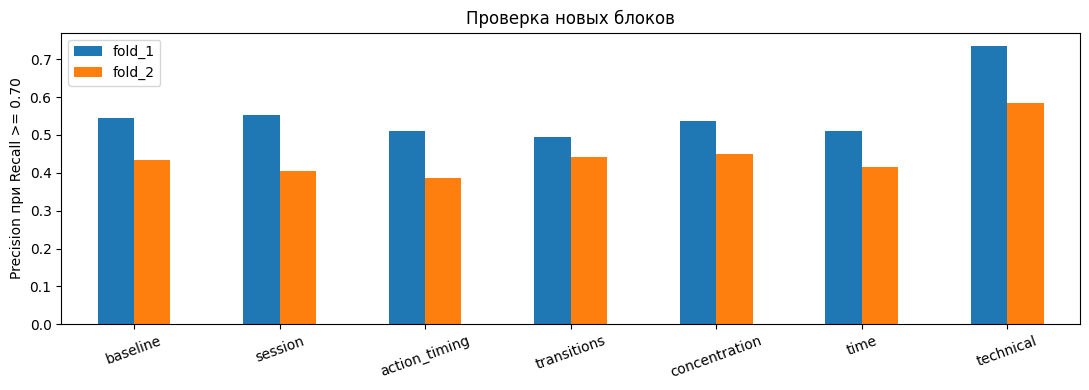

In [26]:
block_summary = block_results.groupby('Блок').agg(
    metric_mean=('Precision при Recall 0.70', 'mean'),
    metric_min=('Precision при Recall 0.70', 'min'),
    pr_auc_mean=('PR-AUC', 'mean'),
    roc_auc_mean=('ROC-AUC', 'mean')
).sort_values('metric_mean', ascending=False)

display(block_summary.round(4))

ax = block_results.pivot(
    index='Блок',
    columns='Разбиение',
    values='Precision при Recall 0.70'
).loc[list(candidate_blocks)].plot.bar(figsize=(11, 4), rot=20)
ax.set(xlabel='', ylabel='Precision при Recall >= 0.70', title='Проверка новых блоков')
ax.legend()
plt.tight_layout()
plt.show()

Baseline получает в среднем 0,4889. Сессии, ритм отдельных действий, переходы, концентрация и время не улучшают оба fold при отдельном добавлении.

Технический блок повышает среднюю метрику до 0,6589 и худший fold до 0,5839. Его разбираем подробнее.

## Разбираем технический блок

Отдельно проверяем семейства User-Agent, точный User-Agent и координаты. Категории User-Agent передаются в CatBoost без target encoding.

In [27]:
family_features = [
    'browser_family', 'os_family',
    'n_browser_families', 'n_os_families'
]
pointer_features = [
    'pointer_unique_positions', 'pointer_unique_share',
    'pointer_x_std', 'pointer_y_std'
]

technical_variants = {
    'baseline': baseline_features,
    'families': baseline_features + family_features,
    'pointer': baseline_features + pointer_features,
    'raw_ua': baseline_features + ['user_agent_first'],
    'all_technical': baseline_features + technical_feature_names
}

technical_rows = []

for variant_name, feature_columns in technical_variants.items():
    categorical_columns = [
        column for column in ['platform', 'browser_family', 'os_family', 'user_agent_first']
        if column in feature_columns
    ]

    for fold_name, valid_start, valid_end in folds:
        train_mask = model_data['window_start_ts'].lt(valid_start)
        valid_mask = (
            model_data['window_start_ts'].ge(valid_start) &
            model_data['window_start_ts'].lt(valid_end)
        )

        model = CatBoostClassifier(
            iterations=600,
            depth=6,
            learning_rate=0.05,
            l2_leaf_reg=3,
            loss_function='Logloss',
            eval_metric='PRAUC:type=Classic',
            random_seed=42,
            verbose=False,
            allow_writing_files=False
        )

        model.fit(
            model_data.loc[train_mask, feature_columns],
            model_data.loc[train_mask, 'target'],
            cat_features=categorical_columns,
            eval_set=(
                model_data.loc[valid_mask, feature_columns],
                model_data.loc[valid_mask, 'target']
            ),
            early_stopping_rounds=100,
            verbose=False
        )

        valid_score = model.predict_proba(
            model_data.loc[valid_mask, feature_columns]
        )[:, 1]
        y_valid = model_data.loc[valid_mask, 'target']

        technical_rows.append([
            variant_name,
            fold_name,
            len(feature_columns),
            precision_at_recall(y_valid, valid_score),
            average_precision_score(y_valid, valid_score),
            roc_auc_score(y_valid, valid_score)
        ])

technical_results = pd.DataFrame(
    technical_rows,
    columns=[
        'Вариант', 'Разбиение', 'Признаков',
        'Precision при Recall 0.70', 'PR-AUC', 'ROC-AUC'
    ]
)

display(technical_results.round(4))

,Вариант,Разбиение,Признаков,Precision при Recall 0.70,PR-AUC,ROC-AUC
0,baseline,fold_1,56,0.5442,0.6961,0.8674
1,baseline,fold_2,56,0.4335,0.6704,0.8857
2,families,fold_1,60,0.5694,0.6985,0.8681
3,families,fold_2,60,0.4265,0.6657,0.8796
4,pointer,fold_1,60,0.7143,0.7552,0.9024
5,pointer,fold_2,60,0.5762,0.7315,0.9175
6,raw_ua,fold_1,57,0.5387,0.6930,0.8634
7,raw_ua,fold_2,57,0.4579,0.6791,0.8813
8,all_technical,fold_1,65,0.7339,0.7556,0.9053
9,all_technical,fold_2,65,0.5839,0.7389,0.9208


In [28]:
technical_summary = technical_results.groupby('Вариант').agg(
    metric_mean=('Precision при Recall 0.70', 'mean'),
    metric_min=('Precision при Recall 0.70', 'min'),
    pr_auc_mean=('PR-AUC', 'mean')
).sort_values('metric_mean', ascending=False)

display(technical_summary.round(4))

,metric_mean,metric_min,pr_auc_mean
Вариант,,,
all_technical,0.6589,0.5839,0.7473
pointer,0.6452,0.5762,0.7433
raw_ua,0.4983,0.4579,0.6860
families,0.4979,0.4265,0.6821
baseline,0.4889,0.4335,0.6833


Основной прирост дают координаты. Их добавление повышает среднюю метрику до 0,6452. User-Agent без координат почти не меняет baseline. Полный технический блок получает 0,6589 и остаётся рабочим вариантом.

## Проверяем концентрацию после технического блока

Концентрация отдельно не помогла baseline. Сравниваем технический вариант с добавлением концентрации. Оба варианта передаём в подбор параметров, если разница между ними зависит от настроек модели.

In [29]:
combined_variants = {
    'baseline': baseline_features,
    'technical': baseline_features + technical_feature_names,
    'technical_concentration': (
        baseline_features + technical_feature_names + concentration_feature_names
    )
}

combined_rows = []

for variant_name, feature_columns in combined_variants.items():
    categorical_columns = [
        column for column in ['platform', 'browser_family', 'os_family', 'user_agent_first']
        if column in feature_columns
    ]

    for fold_name, valid_start, valid_end in folds:
        train_mask = model_data['window_start_ts'].lt(valid_start)
        valid_mask = (
            model_data['window_start_ts'].ge(valid_start) &
            model_data['window_start_ts'].lt(valid_end)
        )

        model = CatBoostClassifier(
            iterations=600,
            depth=6,
            learning_rate=0.05,
            l2_leaf_reg=3,
            loss_function='Logloss',
            eval_metric='PRAUC:type=Classic',
            random_seed=42,
            verbose=False,
            allow_writing_files=False
        )

        model.fit(
            model_data.loc[train_mask, feature_columns],
            model_data.loc[train_mask, 'target'],
            cat_features=categorical_columns,
            eval_set=(
                model_data.loc[valid_mask, feature_columns],
                model_data.loc[valid_mask, 'target']
            ),
            early_stopping_rounds=100,
            verbose=False
        )

        valid_score = model.predict_proba(
            model_data.loc[valid_mask, feature_columns]
        )[:, 1]
        y_valid = model_data.loc[valid_mask, 'target']

        combined_rows.append([
            variant_name,
            fold_name,
            len(feature_columns),
            model.get_best_iteration() + 1,
            precision_at_recall(y_valid, valid_score),
            average_precision_score(y_valid, valid_score),
            roc_auc_score(y_valid, valid_score),
            recall_at_fpr(y_valid, valid_score)
        ])

combined_results = pd.DataFrame(
    combined_rows,
    columns=[
        'Вариант', 'Разбиение', 'Признаков', 'Итераций',
        'Precision при Recall 0.70', 'PR-AUC', 'ROC-AUC', 'Recall при FPR 0.01'
    ]
)

display(combined_results.round(4))

,Вариант,Разбиение,Признаков,Итераций,Precision при Recall 0.70,PR-AUC,ROC-AUC,Recall при FPR 0.01
0,baseline,fold_1,56,218,0.5442,0.6961,0.8674,0.5263
1,baseline,fold_2,56,209,0.4335,0.6704,0.8857,0.5081
2,technical,fold_1,65,208,0.7339,0.7556,0.9053,0.5965
3,technical,fold_2,65,306,0.5839,0.7389,0.9208,0.5645
4,technical_concentration,fold_1,84,421,0.6987,0.7601,0.9075,0.6053
5,technical_concentration,fold_2,84,219,0.5743,0.7355,0.9161,0.5605


In [30]:
combined_summary = combined_results.groupby('Вариант').agg(
    metric_mean=('Precision при Recall 0.70', 'mean'),
    metric_min=('Precision при Recall 0.70', 'min'),
    pr_auc_mean=('PR-AUC', 'mean'),
    recall_fpr_mean=('Recall при FPR 0.01', 'mean')
).sort_values(['metric_min', 'metric_mean'], ascending=False)

display(combined_summary.round(4))

trial_features = combined_variants['technical_concentration']
trial_categorical_features = [
    'platform', 'browser_family', 'os_family', 'user_agent_first'
]

print('Признаков в расширенном варианте', len(trial_features))

,metric_mean,metric_min,pr_auc_mean,recall_fpr_mean
Вариант,,,,
technical,0.6589,0.5839,0.7473,0.5805
technical_concentration,0.6365,0.5743,0.7478,0.5829
baseline,0.4889,0.4335,0.6833,0.5172


Признаков в расширенном варианте 84


При исходных параметрах технический блок получает 0,5839 на худшем fold. Добавление концентрации даёт 0,5743. PR-AUC почти не меняется.

Технический набор и его расширение остаются двумя кандидатами для общего подбора глубины и learning rate. Сессионные, временные и переходные признаки исключаются.

## Сравниваем расширенный вариант с линейной моделью

Логистическая регрессия показывает, нужна ли модели нелинейность. Числовые признаки заполняются медианой и масштабируются. Категории кодируются через OneHotEncoder. Преобразования обучаются внутри fold.

In [31]:
numeric_features = [
    column for column in trial_features
    if column not in trial_categorical_features
]

logistic_rows = []

for regularization in [0.1, 1, 10]:
    for fold_name, valid_start, valid_end in folds:
        train_mask = model_data['window_start_ts'].lt(valid_start)
        valid_mask = (
            model_data['window_start_ts'].ge(valid_start) &
            model_data['window_start_ts'].lt(valid_end)
        )

        preprocessing = ColumnTransformer([
            (
                'numeric',
                make_pipeline(
                    SimpleImputer(strategy='median'),
                    StandardScaler()
                ),
                numeric_features
            ),
            (
                'categorical',
                OneHotEncoder(handle_unknown='ignore'),
                trial_categorical_features
            )
        ])

        logistic_model = make_pipeline(
            preprocessing,
            LogisticRegression(
                C=regularization,
                max_iter=2000,
                random_state=42
            )
        )

        logistic_model.fit(
            model_data.loc[train_mask, trial_features],
            model_data.loc[train_mask, 'target']
        )

        valid_score = logistic_model.predict_proba(
            model_data.loc[valid_mask, trial_features]
        )[:, 1]
        y_valid = model_data.loc[valid_mask, 'target']

        logistic_rows.append([
            regularization,
            fold_name,
            precision_at_recall(y_valid, valid_score),
            average_precision_score(y_valid, valid_score),
            roc_auc_score(y_valid, valid_score)
        ])

logistic_results = pd.DataFrame(
    logistic_rows,
    columns=['C', 'Разбиение', 'Precision при Recall 0.70', 'PR-AUC', 'ROC-AUC']
)

display(logistic_results.round(4))

,C,Разбиение,Precision при Recall 0.70,PR-AUC,ROC-AUC
0,0.1,fold_1,0.4878,0.6707,0.8851
1,0.1,fold_2,0.4372,0.6837,0.8924
2,1.0,fold_1,0.5144,0.6729,0.8826
3,1.0,fold_2,0.4971,0.6934,0.8974
4,10.0,fold_1,0.4360,0.6452,0.8690
5,10.0,fold_2,0.4234,0.6732,0.8923


Лучший линейный вариант получает около 0,51 и 0,50 на двух fold. CatBoost лучше использует нелинейные связи между платформой, координатами, ритмом и интересами.

## Подбираем набор признаков и параметры CatBoost

Технический набор и вариант с концентрацией проверяются при одинаковых настройках. Выбор делается по худшему fold. Регуляризация l2_leaf_reg остаётся равной 3.

In [32]:
tuning_feature_sets = {
    'technical': combined_variants['technical'],
    'technical_concentration': combined_variants['technical_concentration']
}

tuning_rows = []

for feature_set, feature_columns in tuning_feature_sets.items():
    categorical_columns = [
        column for column in ['platform', 'browser_family', 'os_family', 'user_agent_first']
        if column in feature_columns
    ]

    for depth in [5, 6, 7]:
        for learning_rate in [0.03, 0.05]:
            for fold_name, valid_start, valid_end in folds:
                train_mask = model_data['window_start_ts'].lt(valid_start)
                valid_mask = (
                    model_data['window_start_ts'].ge(valid_start) &
                    model_data['window_start_ts'].lt(valid_end)
                )

                model = CatBoostClassifier(
                    iterations=900,
                    depth=depth,
                    learning_rate=learning_rate,
                    l2_leaf_reg=3,
                    loss_function='Logloss',
                    eval_metric='PRAUC:type=Classic',
                    random_seed=42,
                    verbose=False,
                    allow_writing_files=False
                )

                model.fit(
                    model_data.loc[train_mask, feature_columns],
                    model_data.loc[train_mask, 'target'],
                    cat_features=categorical_columns,
                    eval_set=(
                        model_data.loc[valid_mask, feature_columns],
                        model_data.loc[valid_mask, 'target']
                    ),
                    early_stopping_rounds=150,
                    verbose=False
                )

                valid_score = model.predict_proba(
                    model_data.loc[valid_mask, feature_columns]
                )[:, 1]
                y_valid = model_data.loc[valid_mask, 'target']

                tuning_rows.append([
                    feature_set,
                    depth,
                    learning_rate,
                    fold_name,
                    model.get_best_iteration() + 1,
                    precision_at_recall(y_valid, valid_score),
                    average_precision_score(y_valid, valid_score),
                    roc_auc_score(y_valid, valid_score),
                    recall_at_fpr(y_valid, valid_score)
                ])

tuning_results = pd.DataFrame(
    tuning_rows,
    columns=[
        'Набор', 'depth', 'learning_rate', 'Разбиение', 'Итераций',
        'Precision при Recall 0.70', 'PR-AUC', 'ROC-AUC', 'Recall при FPR 0.01'
    ]
)

display(tuning_results.round(4))

,Набор,depth,learning_rate,Разбиение,Итераций,Precision при Recall 0.70,PR-AUC,ROC-AUC,Recall при FPR 0.01
0,technical,5,0.03,fold_1,445,0.6970,0.7548,0.9047,0.5833
1,technical,5,0.03,fold_2,475,0.5521,0.7392,0.9211,0.5766
2,technical,5,0.05,fold_1,384,0.7124,0.7554,0.9037,0.5746
3,technical,5,0.05,fold_2,348,0.5595,0.7343,0.9169,0.5524
4,technical,6,0.03,fold_1,341,0.7220,0.7548,0.9064,0.5702
5,technical,6,0.03,fold_2,351,0.5762,0.7418,0.9222,0.5766
6,technical,6,0.05,fold_1,208,0.7339,0.7556,0.9053,0.5965
7,technical,6,0.05,fold_2,306,0.5839,0.7389,0.9208,0.5645
8,technical,7,0.03,fold_1,425,0.7156,0.7569,0.9089,0.5921
9,technical,7,0.03,fold_2,588,0.5959,0.7403,0.9205,0.5685


In [33]:
tuning_summary = tuning_results.groupby(['Набор', 'depth', 'learning_rate']).agg(
    metric_mean=('Precision при Recall 0.70', 'mean'),
    metric_min=('Precision при Recall 0.70', 'min'),
    pr_auc_mean=('PR-AUC', 'mean'),
    roc_auc_mean=('ROC-AUC', 'mean'),
    iterations=('Итераций', 'median')
).sort_values(['metric_min', 'metric_mean'], ascending=False)

display(tuning_summary.round(4))

selected_feature_set = tuning_summary.index[0][0]
selected_depth = int(tuning_summary.index[0][1])
selected_learning_rate = float(tuning_summary.index[0][2])
selected_features = tuning_feature_sets[selected_feature_set]
selected_categorical_features = [
    column for column in ['platform', 'browser_family', 'os_family', 'user_agent_first']
    if column in selected_features
]

print('Выбранный набор', selected_feature_set)
print('Число признаков', len(selected_features))
print('Выбранная глубина', selected_depth)
print('Выбранный learning rate', selected_learning_rate)

metric_mean  metric_min  \
Набор                   depth learning_rate                            
technical_concentration 7     0.05                0.6949      0.6421   
                              0.03                0.6839      0.6167   
                        5     0.05                0.6450      0.5973   
technical               7     0.03                0.6557      0.5959   
                        6     0.05                0.6589      0.5839   
                              0.03                0.6491      0.5762   
technical_concentration 6     0.05                0.6365      0.5743   
technical               7     0.05                0.6528      0.5682   
technical_concentration 6     0.03                0.6356      0.5663   
                        5     0.03                0.6469      0.5631   
technical               5     0.05                0.6359      0.5595   
                              0.03                0.6245      0.5521   

                                             pr_auc_mean  roc_auc_mean  \
Набор                   depth learning_rate                              
technical_concentration 7     0.05                0.7515        0.9156   
                              0.03                0.7478        0.9118   
                        5     0.05                0.7407        0.9103   
technical               7     0.03                0.7486        0.9147   
                        6     0.05                0.7473        0.9131   
                              0.03                0.7483        0.9143   
technical_concentration 6     0.05                0.7486        0.9121   
technical               7     0.05                0.7465        0.9132   
technical_concentration 6     0.03                0.7482        0.9111   
                        5     0.03                0.7451        0.9111   
technical               5     0.05                0.7448        0.9103   
                              0.03                0.7470        0.9129   

                                             iterations  
Набор                   depth learning_rate              
technical_concentration 7     0.05                243.0  
                              0.03                502.5  
                        5     0.05                427.0  
technical               7     0.03                506.5  
                        6     0.05                257.0  
                              0.03                346.0  
technical_concentration 6     0.05                434.5  
technical               7     0.05                262.5  
technical_concentration 6     0.03                622.5  
                        5     0.03                577.0  
technical               5     0.05                366.0  
                              0.03                460.0

Выбранный набор technical_concentration
Число признаков 84
Выбранная глубина 7
Выбранный learning rate 0.05


Расширенный технический набор с концентрацией получает лучший худший fold. Выбранная глубина равна 7, learning rate равен 0,05. Метрики двух fold равны 0,7477 и 0,6421.

После одинакового подбора параметров расширение оказалось полезным. В модель входят 84 признака.

## Проверяем вес положительного класса

В baseline дополнительный вес не помог. После изменения признаков проверяем веса 1, 2 и 4 ещё раз.

In [34]:
weight_rows = []

for positive_weight in [1, 2, 4]:
    for fold_name, valid_start, valid_end in folds:
        train_mask = model_data['window_start_ts'].lt(valid_start)
        valid_mask = (
            model_data['window_start_ts'].ge(valid_start) &
            model_data['window_start_ts'].lt(valid_end)
        )

        model = CatBoostClassifier(
            iterations=900,
            depth=selected_depth,
            learning_rate=selected_learning_rate,
            l2_leaf_reg=3,
            loss_function='Logloss',
            eval_metric='PRAUC:type=Classic',
            class_weights=[1, positive_weight],
            random_seed=42,
            verbose=False,
            allow_writing_files=False
        )

        model.fit(
            model_data.loc[train_mask, selected_features],
            model_data.loc[train_mask, 'target'],
            cat_features=selected_categorical_features,
            eval_set=(
                model_data.loc[valid_mask, selected_features],
                model_data.loc[valid_mask, 'target']
            ),
            early_stopping_rounds=150,
            verbose=False
        )

        valid_score = model.predict_proba(
            model_data.loc[valid_mask, selected_features]
        )[:, 1]
        y_valid = model_data.loc[valid_mask, 'target']

        weight_rows.append([
            positive_weight,
            fold_name,
            model.get_best_iteration() + 1,
            precision_at_recall(y_valid, valid_score),
            average_precision_score(y_valid, valid_score),
            roc_auc_score(y_valid, valid_score),
            recall_at_fpr(y_valid, valid_score)
        ])

weight_results = pd.DataFrame(
    weight_rows,
    columns=[
        'Вес', 'Разбиение', 'Итераций',
        'Precision при Recall 0.70', 'PR-AUC', 'ROC-AUC', 'Recall при FPR 0.01'
    ]
)

display(weight_results.round(4))

,Вес,Разбиение,Итераций,Precision при Recall 0.70,PR-AUC,ROC-AUC,Recall при FPR 0.01
0,1,fold_1,254,0.7477,0.7588,0.9085,0.6009
1,1,fold_2,232,0.6421,0.7442,0.9228,0.5605
2,2,fold_1,213,0.7265,0.7633,0.9134,0.6053
3,2,fold_2,131,0.6105,0.7369,0.9179,0.5524
4,4,fold_1,590,0.7105,0.7653,0.9055,0.6140
5,4,fold_2,185,0.6021,0.7400,0.9191,0.5605


In [35]:
weight_summary = weight_results.groupby('Вес').agg(
    metric_mean=('Precision при Recall 0.70', 'mean'),
    metric_min=('Precision при Recall 0.70', 'min'),
    pr_auc_mean=('PR-AUC', 'mean'),
    iterations=('Итераций', 'median')
).sort_values(['metric_min', 'metric_mean'], ascending=False)

display(weight_summary.round(4))

selected_weight = int(weight_summary.index[0])
print('Выбранный вес', selected_weight)

,metric_mean,metric_min,pr_auc_mean,iterations
Вес,,,,
1,0.6949,0.6421,0.7515,243.0
2,0.6685,0.6105,0.7501,172.0
4,0.6563,0.6021,0.7526,387.5


Выбранный вес 1


Вес 1 получает лучший худший fold 0,6421 и среднюю метрику 0,6949. Дополнительный вес положительного класса не улучшает основную метрику.

## Проверяем зависимость от random seed

Обучаем три модели с одинаковыми признаками и параметрами. Отдельно считаем средний score трёх моделей.

In [36]:
seed_rows = []
seed_models = {}
seed_predictions = {}
fold_targets = {}

for fold_name, valid_start, valid_end in folds:
    train_mask = model_data['window_start_ts'].lt(valid_start)
    valid_mask = (
        model_data['window_start_ts'].ge(valid_start) &
        model_data['window_start_ts'].lt(valid_end)
    )
    y_valid = model_data.loc[valid_mask, 'target'].copy()
    fold_targets[fold_name] = y_valid

    for random_seed in [17, 42, 73]:
        model = CatBoostClassifier(
            iterations=900,
            depth=selected_depth,
            learning_rate=selected_learning_rate,
            l2_leaf_reg=3,
            loss_function='Logloss',
            eval_metric='PRAUC:type=Classic',
            class_weights=[1, selected_weight],
            random_seed=random_seed,
            verbose=False,
            allow_writing_files=False
        )

        model.fit(
            model_data.loc[train_mask, selected_features],
            model_data.loc[train_mask, 'target'],
            cat_features=selected_categorical_features,
            eval_set=(
                model_data.loc[valid_mask, selected_features],
                y_valid
            ),
            early_stopping_rounds=150,
            verbose=False
        )

        valid_score = model.predict_proba(
            model_data.loc[valid_mask, selected_features]
        )[:, 1]

        seed_models[(fold_name, random_seed)] = model
        seed_predictions[(fold_name, random_seed)] = valid_score

        seed_rows.append([
            fold_name,
            str(random_seed),
            model.get_best_iteration() + 1,
            precision_at_recall(y_valid, valid_score),
            average_precision_score(y_valid, valid_score),
            roc_auc_score(y_valid, valid_score),
            recall_at_fpr(y_valid, valid_score)
        ])

    ensemble_score = np.mean([
        seed_predictions[(fold_name, random_seed)]
        for random_seed in [17, 42, 73]
    ], axis=0)

    seed_predictions[(fold_name, 'ensemble')] = ensemble_score

    seed_rows.append([
        fold_name,
        'ensemble',
        np.nan,
        precision_at_recall(y_valid, ensemble_score),
        average_precision_score(y_valid, ensemble_score),
        roc_auc_score(y_valid, ensemble_score),
        recall_at_fpr(y_valid, ensemble_score)
    ])

seed_results = pd.DataFrame(
    seed_rows,
    columns=[
        'Разбиение', 'Модель', 'Итераций',
        'Precision при Recall 0.70', 'PR-AUC', 'ROC-AUC', 'Recall при FPR 0.01'
    ]
)

display(seed_results.round(4))

,Разбиение,Модель,Итераций,Precision при Recall 0.70,PR-AUC,ROC-AUC,Recall при FPR 0.01
0,fold_1,17,590.0,0.6897,0.7556,0.9068,0.6140
1,fold_1,42,254.0,0.7477,0.7588,0.9085,0.6009
2,fold_1,73,898.0,0.6680,0.7591,0.9099,0.6140
3,fold_1,ensemble,NaN,0.7207,0.7620,0.9103,0.6272
4,fold_2,17,380.0,0.5682,0.7400,0.9138,0.5847
5,fold_2,42,232.0,0.6421,0.7442,0.9228,0.5605
6,fold_2,73,182.0,0.5939,0.7369,0.9178,0.5766
7,fold_2,ensemble,NaN,0.6282,0.7441,0.9202,0.5927


In [37]:
seed_summary = seed_results.groupby('Модель').agg(
    metric_mean=('Precision при Recall 0.70', 'mean'),
    metric_min=('Precision при Recall 0.70', 'min'),
    pr_auc_mean=('PR-AUC', 'mean'),
    recall_fpr_mean=('Recall при FPR 0.01', 'mean')
).sort_values(['metric_min', 'metric_mean'], ascending=False)

display(seed_summary.round(4))

selected_seed = 42
selected_iterations = int(
    seed_results.loc[
        seed_results['Модель'].eq(str(selected_seed)),
        'Итераций'
    ].median()
)

validation_model = seed_models[('fold_2', selected_seed)]
validation_score = seed_predictions[('fold_2', selected_seed)]
validation_target = fold_targets['fold_2']

print('Выбранный seed', selected_seed)
print('Число итераций', selected_iterations)

,metric_mean,metric_min,pr_auc_mean,recall_fpr_mean
Модель,,,,
42,0.6949,0.6421,0.7515,0.5807
ensemble,0.6744,0.6282,0.7531,0.6100
73,0.6310,0.5939,0.7480,0.5953
17,0.6289,0.5682,0.7478,0.5994


Выбранный seed 42
Число итераций 243


Seed 42 получает лучший худший fold 0,6421. Усреднение трёх seed улучшает PR-AUC и Recall при FPR 0,01, но снижает основную метрику. В финальной модели используем seed 42 и 243 итерации.

## Оцениваем разброс метрики

Bootstrap выполняется отдельно для каждого fold. Положительные и отрицательные объекты пересэмплируются раздельно. Модель не переобучается, поэтому интервал описывает неопределённость оценки на имеющихся предсказаниях.

In [38]:
random_generator = np.random.default_rng(42)
bootstrap_rows = []

for fold_name in ['fold_1', 'fold_2']:
    y_fold = fold_targets[fold_name].to_numpy()
    score_fold = seed_predictions[(fold_name, selected_seed)]
    positive_positions = np.where(y_fold == 1)[0]
    negative_positions = np.where(y_fold == 0)[0]
    bootstrap_metrics = []

    for iteration in range(500):
        sampled_positive = random_generator.choice(
            positive_positions,
            size=len(positive_positions),
            replace=True
        )
        sampled_negative = random_generator.choice(
            negative_positions,
            size=len(negative_positions),
            replace=True
        )
        sampled_positions = np.r_[sampled_positive, sampled_negative]
        bootstrap_metrics.append(
            precision_at_recall(
                y_fold[sampled_positions],
                score_fold[sampled_positions]
            )
        )

    bootstrap_rows.append([
        fold_name,
        precision_at_recall(y_fold, score_fold),
        np.quantile(bootstrap_metrics, 0.05),
        np.median(bootstrap_metrics),
        np.quantile(bootstrap_metrics, 0.95)
    ])

bootstrap_results = pd.DataFrame(
    bootstrap_rows,
    columns=['Разбиение', 'Метрика', '5%', 'Медиана bootstrap', '95%']
)

display(bootstrap_results.round(4))

,Разбиение,Метрика,5%,Медиана bootstrap,95%
0,fold_1,0.7477,0.5648,0.7448,0.8342
1,fold_2,0.6421,0.5070,0.6421,0.7160


Bootstrap показывает диапазон возможных значений при изменении состава выборки. Разница между fold остаётся важнее небольшой разницы между близкими настройками CatBoost.

## Смотрим важность выбранной модели

Важность берётся у модели второго fold. Коррелирующие признаки могут делить вклад между собой.

,Признак,Важность
63,pointer_x_std,8.850
17,session_duration_median,4.590
8,gap_p10,3.791
10,gap_q75,3.700
7,gap_median,3.653
51,age_days,3.019
48,mean_search_page,2.764
60,user_agent_first,2.396
45,pro_seller_share,2.337
9,gap_q25,2.326


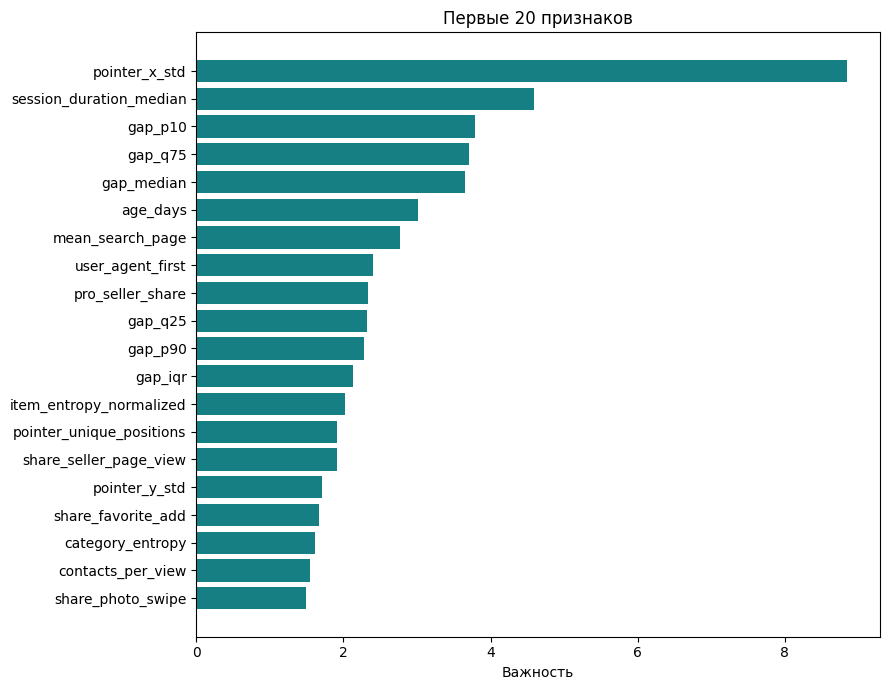

In [39]:
feature_importance = pd.DataFrame({
    'Признак': selected_features,
    'Важность': validation_model.get_feature_importance()
}).sort_values('Важность', ascending=False)

display(feature_importance.head(25).round(3))

importance_plot = feature_importance.head(20).sort_values('Важность')
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(importance_plot['Признак'], importance_plot['Важность'], color='#157F83')
ax.set(xlabel='Важность', ylabel='', title='Первые 20 признаков')
plt.tight_layout()
plt.show()

В верхней части остаются паузы и глубина поиска. pointer_x_std, User-Agent, платформа и энтропии добавляют новые сигналы. Улучшение не строится на одном столбце.

## Разбираем ошибки второго fold

Порог выбирается только для анализа. Submission содержит непрерывный score.

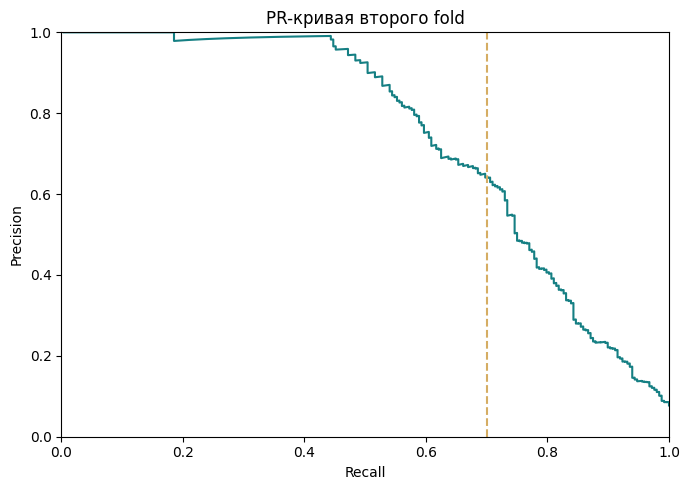

,Порог,Precision,Recall,Отмечено кук
0,0.1443,0.6421,0.7016,271


In [40]:
precision, recall = pr_curve(validation_target, validation_score)

order = np.argsort(-validation_score, kind='mergesort')
y_sorted = validation_target.to_numpy()[order]
score_sorted = validation_score[order]
true_positive = np.cumsum(y_sorted)
marked = np.arange(1, len(y_sorted) + 1)
group_ends = np.r_[score_sorted[1:] != score_sorted[:-1], True]

thresholds = score_sorted[group_ends]
threshold_precision = true_positive[group_ends] / marked[group_ends]
threshold_recall = true_positive[group_ends] / y_sorted.sum()
allowed_positions = np.where(threshold_recall >= 0.70)[0]
best_position = allowed_positions[np.argmax(threshold_precision[allowed_positions])]

validation_threshold = thresholds[best_position]
validation_prediction = validation_score >= validation_threshold

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color='#157F83')
ax.axvline(0.70, color='#D5AD63', linestyle='--')
ax.set(
    xlabel='Recall',
    ylabel='Precision',
    title='PR-кривая второго fold',
    xlim=(0, 1),
    ylim=(0, 1)
)
plt.tight_layout()
plt.show()

threshold_table = pd.DataFrame({
    'Порог': [validation_threshold],
    'Precision': [threshold_precision[best_position]],
    'Recall': [threshold_recall[best_position]],
    'Отмечено кук': [validation_prediction.sum()]
})

display(threshold_table.round(4))

In [41]:
validation_index = validation_target.index
validation_errors = model_data.loc[
    validation_index,
    [
        'platform', 'n_events', 'gap_median', 'max_search_page',
        'age_days', 'pointer_x_std', 'category_entropy',
        'unique_locations', 'target'
    ]
].copy()

validation_errors['score'] = validation_score
validation_errors['prediction'] = validation_prediction.astype(int)
validation_errors['group'] = np.select(
    [
        validation_errors['target'].eq(1) & validation_errors['prediction'].eq(1),
        validation_errors['target'].eq(1) & validation_errors['prediction'].eq(0),
        validation_errors['target'].eq(0) & validation_errors['prediction'].eq(1)
    ],
    ['Найденный бот', 'Пропущенный бот', 'Ложное срабатывание'],
    default='Верный человек'
)

error_summary = validation_errors.groupby('group').agg(
    cookies=('target', 'size'),
    score_median=('score', 'median'),
    events_median=('n_events', 'median'),
    gap_median=('gap_median', 'median'),
    max_page_median=('max_search_page', 'median'),
    age_median=('age_days', 'median'),
    pointer_std_median=('pointer_x_std', 'median'),
    locations_median=('unique_locations', 'median')
)

display(error_summary.round(2))

,cookies,score_median,events_median,gap_median,max_page_median,age_median,pointer_std_median,locations_median
group,,,,,,,,
Верный человек,2865,0.02,11.0,62.0,4.0,66.07,554.63,2.0
Ложное срабатывание,97,0.26,21.0,25.0,7.0,23.67,290.22,4.0
Найденный бот,174,0.88,27.0,18.5,9.0,10.70,165.88,6.0
Пропущенный бот,74,0.04,13.0,45.0,4.0,49.85,384.24,3.0


Пропущенные боты остаются ближе к людям по возрасту, скорости и глубине поиска. Ложные срабатывания имеют промежуточные значения. Следующие признаки должны описывать тихих ботов, а не только усиливать экстремальную активность.

## Сравниваем новые признаки в train и test

Test используется без target. Проверяем форму распределений, пропуски и неизвестные категории.

In [42]:
shift_columns = [
    'pointer_unique_positions', 'pointer_unique_share',
    'pointer_x_std', 'pointer_y_std',
    'action_entropy', 'item_entropy',
    'category_entropy', 'location_entropy',
    'query_entropy', 'query_repeat_share'
]

shift_rows = []

for feature in shift_columns:
    train_values = cookie_features.loc[
        cookie_features['dataset'].eq('train'), feature
    ]
    test_values = cookie_features.loc[
        cookie_features['dataset'].eq('test'), feature
    ]

    ks_value = ks_2samp(
        train_values.dropna(),
        test_values.dropna()
    ).statistic

    shift_rows.append([
        feature,
        train_values.median(),
        test_values.median(),
        ks_value,
        train_values.isna().mean() * 100,
        test_values.isna().mean() * 100
    ])

shift_table = pd.DataFrame(
    shift_rows,
    columns=[
        'Признак', 'Медиана train', 'Медиана test', 'KS',
        'Пропуски train, %', 'Пропуски test, %'
    ]
).sort_values('KS', ascending=False)

display(shift_table.round(4))

unseen_rows = []

for feature in selected_categorical_features:
    train_values = set(
        cookie_features.loc[
            cookie_features['dataset'].eq('train'), feature
        ].dropna()
    )
    test_values = cookie_features.loc[
        cookie_features['dataset'].eq('test'), feature
    ].dropna()
    unseen = ~test_values.isin(train_values)

    unseen_rows.append([
        feature,
        len(train_values),
        test_values.nunique(),
        test_values.loc[unseen].nunique(),
        unseen.mean() * 100
    ])

unseen_table = pd.DataFrame(
    unseen_rows,
    columns=[
        'Признак', 'Уникальных train', 'Уникальных test',
        'Новых в test', 'Доля строк с новым значением, %'
    ]
)

display(unseen_table.round(4))

,Признак,Медиана train,Медиана test,KS,"Пропуски train, %","Пропуски test, %"
2,pointer_x_std,546.0663,537.9734,0.0457,64.6380,63.9641
3,pointer_y_std,305.4231,304.7064,0.0233,64.6380,63.9641
8,query_entropy,1.0986,1.0986,0.0211,8.3040,8.8613
6,category_entropy,0.5004,0.5004,0.0165,7.3844,6.9464
7,location_entropy,0.9003,0.9003,0.0134,6.9696,6.6001
4,action_entropy,1.2945,1.2832,0.0127,0.0000,0.0000
5,item_entropy,1.3863,1.3863,0.0103,6.5729,6.2538
9,query_repeat_share,0.0000,0.0000,0.0081,8.3040,8.8613
0,pointer_unique_positions,0.0000,0.0000,0.0072,0.0000,0.0000
1,pointer_unique_share,1.0000,1.0000,0.0020,63.5200,63.0271


,Признак,Уникальных train,Уникальных test,Новых в test,"Доля строк с новым значением, %"
0,platform,3,3,0,0.0
1,browser_family,5,5,0,0.0
2,os_family,6,6,0,0.0
3,user_agent_first,148,148,0,0.0


Максимальный KS новых признаков равен примерно 0,046 для pointer_x_std. Разница долей пропусков меньше одного процентного пункта. В категориальных признаках нет значений test, отсутствующих в train.

## Проводим одну проверку на 17-19 апреля

Признаки, параметры, вес класса, seed и число итераций уже выбраны. Holdout не участвует в следующем выборе.

In [43]:
development_mask = model_data['window_start_ts'].lt(
    pd.Timestamp('2026-04-17')
)
holdout_mask = model_data['window_start_ts'].ge(
    pd.Timestamp('2026-04-17')
)

holdout_model = CatBoostClassifier(
    iterations=selected_iterations,
    depth=selected_depth,
    learning_rate=selected_learning_rate,
    l2_leaf_reg=3,
    loss_function='Logloss',
    class_weights=[1, selected_weight],
    random_seed=selected_seed,
    verbose=False,
    allow_writing_files=False
)

holdout_model.fit(
    model_data.loc[development_mask, selected_features],
    model_data.loc[development_mask, 'target'],
    cat_features=selected_categorical_features,
    verbose=False
)

holdout_score = holdout_model.predict_proba(
    model_data.loc[holdout_mask, selected_features]
)[:, 1]
y_holdout = model_data.loc[holdout_mask, 'target']

holdout_order = np.argsort(-holdout_score, kind='mergesort')
holdout_target_sorted = y_holdout.to_numpy()[holdout_order]
holdout_score_sorted = holdout_score[holdout_order]
holdout_tp = np.cumsum(holdout_target_sorted)
holdout_marked = np.arange(1, len(holdout_target_sorted) + 1)
holdout_group_ends = np.r_[holdout_score_sorted[1:] != holdout_score_sorted[:-1], True]
holdout_precision = holdout_tp[holdout_group_ends] / holdout_marked[holdout_group_ends]
holdout_recall = holdout_tp[holdout_group_ends] / holdout_target_sorted.sum()
holdout_allowed = np.where(holdout_recall >= 0.70)[0]
holdout_best = holdout_allowed[np.argmax(holdout_precision[holdout_allowed])]

holdout_results = pd.DataFrame({
    'Период': ['17-19 апреля'],
    'Кук': [len(y_holdout)],
    'Ботов': [y_holdout.sum()],
    'Найдено ботов': [holdout_tp[holdout_group_ends][holdout_best]],
    'Отмечено кук': [holdout_marked[holdout_group_ends][holdout_best]],
    'Precision при Recall 0.70': [precision_at_recall(y_holdout, holdout_score)],
    'PR-AUC': [average_precision_score(y_holdout, holdout_score)],
    'ROC-AUC': [roc_auc_score(y_holdout, holdout_score)],
    'Recall при FPR 0.01': [recall_at_fpr(y_holdout, holdout_score)]
})

display(holdout_results.round(4))

,Период,Кук,Ботов,Найдено ботов,Отмечено кук,Precision при Recall 0.70,PR-AUC,ROC-AUC,Recall при FPR 0.01
0,17-19 апреля,1951,160,112,154,0.7273,0.7611,0.9277,0.5938


Основная метрика на 17-19 апреля равна 0,7273. Модель находит 112 из 160 ботов и отмечает 154 куки в лучшей допустимой точке. PR-AUC равен 0,7611, ROC-AUC равен 0,9277.

Baseline на этом периоде получал 0,4766. Улучшение равно 0,2507.

## Обучаем финальную модель 

Финальная модель обучается на всех размеченных данных 6-19 апреля. Test используется только для получения score.

In [44]:
final_model = CatBoostClassifier(
    iterations=selected_iterations,
    depth=selected_depth,
    learning_rate=selected_learning_rate,
    l2_leaf_reg=3,
    loss_function='Logloss',
    class_weights=[1, selected_weight],
    random_seed=selected_seed,
    verbose=False,
    allow_writing_files=False
)

final_model.fit(
    model_data[selected_features],
    model_data['target'],
    cat_features=selected_categorical_features,
    verbose=False
)

test_features = cookie_features.loc[test['cookie_id'], selected_features]
test_score = final_model.predict_proba(test_features)[:, 1]

test_scores = pd.Series(
    test_score,
    index=test_features.index,
    name='score'
)

submission = sample_submission[['cookie_id']].copy()
submission['score'] = submission['cookie_id'].map(test_scores).clip(0, 1)
submission.to_csv('submission.csv', index=False)

display(submission.head())

,cookie_id,score
0,ck_99a4e5ef02d89493,0.040367
1,ck_54d463f7fd89ec3d,0.082868
2,ck_0fbbc7a6af300368,0.006567
3,ck_8fd4937eadd64fb6,0.005275
4,ck_dbb4bd4eda97255d,0.017993


In [45]:
submission_checks = pd.DataFrame({
    'Проверка': [
        'Число строк совпадает с test',
        'Нет повторных cookie_id',
        'Нет пропусков',
        'Порядок совпадает с sample_submission',
        'Все score находятся от 0 до 1'
    ],
    'Результат': [
        len(submission) == len(test),
        not submission['cookie_id'].duplicated().any(),
        submission.notna().all().all(),
        submission['cookie_id'].equals(sample_submission['cookie_id']),
        submission['score'].between(0, 1).all()
    ]
})

display(submission_checks)
print('Минимальный score', submission['score'].min())
print('Максимальный score', submission['score'].max())


,Проверка,Результат
0,Число строк совпадает с test,True
1,Нет повторных cookie_id,True
2,Нет пропусков,True
3,Порядок совпадает с sample_submission,True
4,Все score находятся от 0 до 1,True


Минимальный score 0.0006983365871201267
Максимальный score 0.9991044161371992


## Итог

Baseline на holdout получал 0,4766. Новая модель получает 0,7273.

Основной прирост дали координаты курсора. Структура User-Agent и признаки концентрации дополнили этот сигнал. Большие блоки переходов, времени и сессий не показали устойчивого прироста и не вошли в финальную модель.

Финальная модель использует 84 признака, CatBoost depth 7, learning rate 0,05, вес положительного класса 1, seed 42 и 243 итерации.